<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_1_Airline_Delay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("FootballPlayersAnalysis")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Mounted at /content/drive
Spark Version: 4.0.4


In [ ]:
DATA_PATH = "/content/PlayersDataset.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.show(5)

Rows: 17981
Columns: 75
+---+-----------------+---+--------------------+-----------+--------------------+-------+---------+-------------------+--------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|             Name|Age|               Photo|Nationality|                Flag|Overall|Potential|               Club|           Club Logo| Value| Wage|Special|Acceleration|Aggression|Agility|Balance|Ball control|Composure|Crossing|Curve|Dribbling|Finishing|Free kick accurac

In [ ]:
# Show the dataset structure
df.printSchema()

# Remove duplicate records
df = df.dropDuplicates()

# Check missing values in each column
missing_values = df.select([
    F.sum(
        F.when(F.col(column).isNull(), 1).otherwise(0)
    ).alias(column)
    for column in df.columns
])

missing_values.show(vertical=True)

# Display final number of rows
print("Rows after removing duplicates:", df.count())

root
 |-- _c0: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Photo: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Flag: string (nullable = true)
 |-- Overall: integer (nullable = true)
 |-- Potential: integer (nullable = true)
 |-- Club: string (nullable = true)
 |-- Club Logo: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Special: integer (nullable = true)
 |-- Acceleration: string (nullable = true)
 |-- Aggression: string (nullable = true)
 |-- Agility: string (nullable = true)
 |-- Balance: string (nullable = true)
 |-- Ball control: string (nullable = true)
 |-- Composure: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Curve: string (nullable = true)
 |-- Dribbling: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Free kick accuracy: string (nullable = true)
 |-- GK diving: string (nullable = true)


In [ ]:
# Display selected important columns
df.select(
    "Name",
    "Age",
    "Nationality",
    "Overall",
    "Potential",
    "Club",
    "Value",
    "Wage"
).show(10, truncate=False)

# Generate statistical summary for numerical columns
df.select(
    "Age",
    "Overall",
    "Potential"
).describe().show()

+---------------+---+-----------+-------+---------+----------------------+------+-----+
|Name           |Age|Nationality|Overall|Potential|Club                  |Value |Wage |
+---------------+---+-----------+-------+---------+----------------------+------+-----+
|G. Higuaín     |29 |Argentina  |90     |90       |Juventus              |€77M  |€275K|
|N. Süle        |21 |Germany    |83     |89       |FC Bayern Munich      |€30.5M|€78K |
|A. Sanabria    |21 |Paraguay   |78     |86       |Real Betis Balompié   |€15.5M|€23K |
|M. Uth         |25 |Germany    |77     |80       |TSG 1899 Hoffenheim   |€11.5M|€40K |
|J. Roussillon  |24 |France     |76     |81       |Montpellier Hérault SC|€8.5M |€23K |
|Serey Dié      |32 |Ivory Coast|76     |76       |FC Basel              |€4.4M |€38K |
|Laguardia      |27 |Spain      |76     |78       |Deportivo Alavés      |€7.5M |€25K |
|Felipe         |32 |Brazil     |75     |75       |Ferrara (SPAL)        |€3.8M |€14K |
|Gabriel        |23 |Brazil     

In [ ]:
top_players = (
    df.select(
        "Name",
        "Age",
        "Nationality",
        "Club",
        "Overall",
        "Potential"
    )
    .orderBy(F.desc("Overall"))
    .limit(10)
)

top_players.show(10, truncate=False)

+-----------------+---+-----------+-------------------+-------+---------+
|Name             |Age|Nationality|Club               |Overall|Potential|
+-----------------+---+-----------+-------------------+-------+---------+
|Cristiano Ronaldo|32 |Portugal   |Real Madrid CF     |94     |94       |
|L. Messi         |30 |Argentina  |FC Barcelona       |93     |93       |
|L. Suárez        |30 |Uruguay    |FC Barcelona       |92     |92       |
|Neymar           |25 |Brazil     |Paris Saint-Germain|92     |94       |
|M. Neuer         |31 |Germany    |FC Bayern Munich   |92     |92       |
|R. Lewandowski   |28 |Poland     |FC Bayern Munich   |91     |91       |
|Sergio Ramos     |31 |Spain      |Real Madrid CF     |90     |90       |
|T. Kroos         |27 |Germany    |Real Madrid CF     |90     |90       |
|De Gea           |26 |Spain      |Manchester United  |90     |92       |
|G. Higuaín       |29 |Argentina  |Juventus           |90     |90       |
+-----------------+---+-----------+---

In [ ]:
nationality_stats = (
    df.groupBy("Nationality")
    .agg(
        F.count("*").alias("Number_of_Players"),
        F.round(
            F.avg("Overall"), 2
        ).alias("Average_Overall")
    )
    .filter(F.col("Number_of_Players") >= 20)
    .orderBy(F.desc("Average_Overall"))
    .limit(10)
)

nationality_stats.show(10, truncate=False)

+--------------+-----------------+---------------+
|Nationality   |Number_of_Players|Average_Overall|
+--------------+-----------------+---------------+
|Algeria       |57               |70.95          |
|Chile         |375              |70.9           |
|Brazil        |812              |70.9           |
|Portugal      |367              |70.6           |
|Ecuador       |37               |70.51          |
|Serbia        |133              |70.44          |
|Czech Republic|73               |70.18          |
|Ukraine       |49               |70.04          |
|Egypt         |32               |69.97          |
|Spain         |1019             |69.94          |
+--------------+-----------------+---------------+



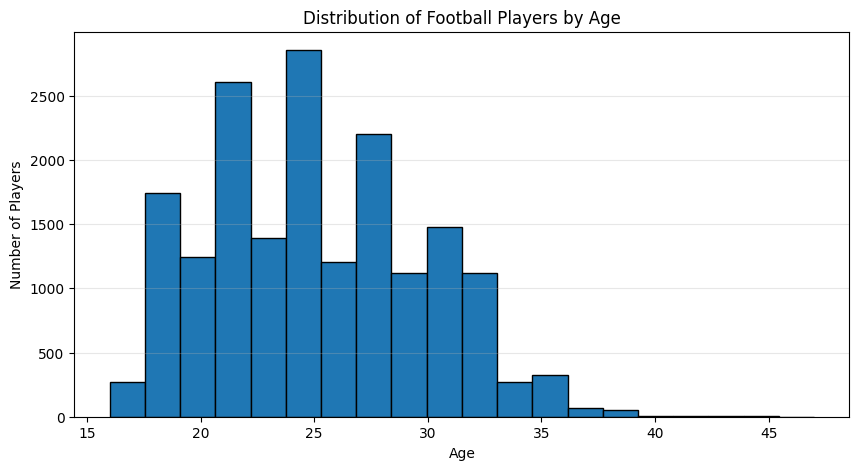

In [ ]:
# Convert only the Age column to Pandas for visualisation
age_pd = (
    df.select("Age")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(10, 5))

plt.hist(
    age_pd["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Football Players by Age")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.grid(axis="y", alpha=0.3)
plt.show()

+-------------------+-----------------+---------------+
|Club               |Number_of_Players|Average_Overall|
+-------------------+-----------------+---------------+
|FC Barcelona       |25               |82.56          |
|Juventus           |26               |81.65          |
|Real Madrid CF     |26               |81.04          |
|FC Bayern Munich   |26               |79.42          |
|Paris Saint-Germain|28               |77.96          |
|Manchester United  |34               |77.71          |
|Napoli             |26               |77.65          |
|Roma               |27               |77.37          |
|Sevilla FC         |26               |76.96          |
|Inter              |25               |76.72          |
+-------------------+-----------------+---------------+



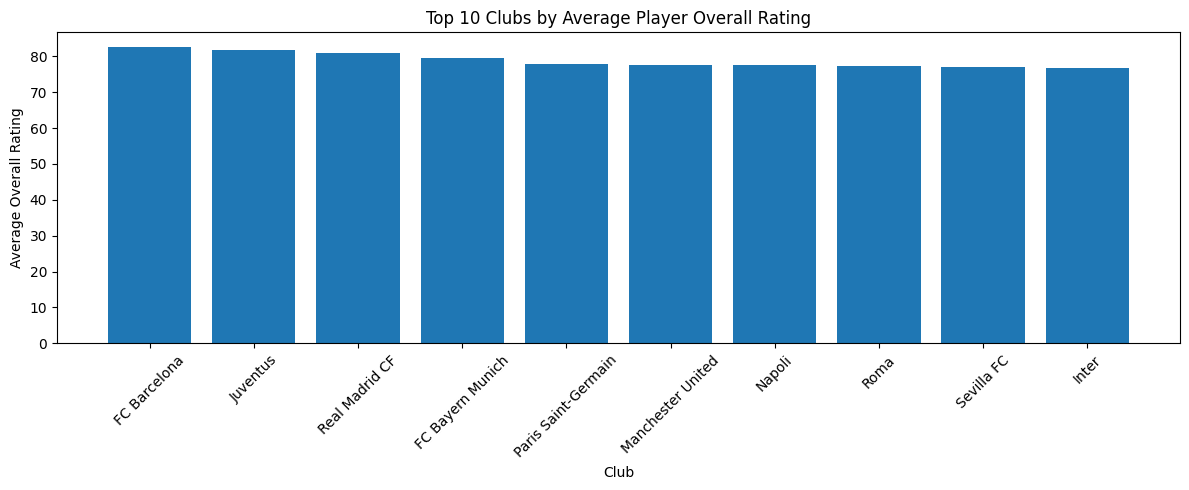

In [ ]:
club_stats = (
    df.groupBy("Club")
    .agg(
        F.count("*").alias("Number_of_Players"),
        F.round(
            F.avg("Overall"), 2
        ).alias("Average_Overall")
    )
    .filter(F.col("Number_of_Players") >= 5)
    .orderBy(F.desc("Average_Overall"))
    .limit(10)
)

club_stats.show(10, truncate=False)

# Convert results for visualisation
club_pd = club_stats.toPandas()

plt.figure(figsize=(12, 5))

plt.bar(
    club_pd["Club"],
    club_pd["Average_Overall"]
)

plt.title("Top 10 Clubs by Average Player Overall Rating")
plt.xlabel("Club")
plt.ylabel("Average Overall Rating")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

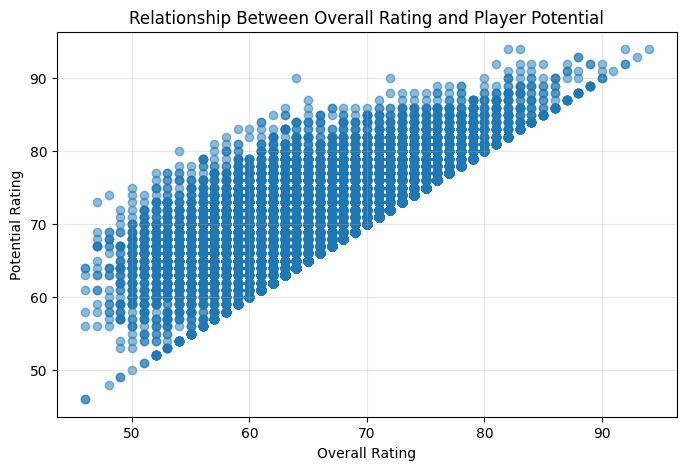

In [ ]:
# Select relevant columns and remove missing values
rating_pd = (
    df.select("Overall", "Potential")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    rating_pd["Overall"],
    rating_pd["Potential"],
    alpha=0.5
)

plt.title("Relationship Between Overall Rating and Player Potential")
plt.xlabel("Overall Rating")
plt.ylabel("Potential Rating")

plt.grid(alpha=0.3)
plt.show()

+-------------------+-----+
|Preferred Positions|count|
+-------------------+-----+
|CB                 |2216 |
|GK                 |2029 |
|ST                 |1847 |
|CM                 |759  |
|LB                 |746  |
|CM CDM             |644  |
|RB                 |637  |
|CDM CM             |549  |
|CDM                |423  |
|CAM                |320  |
+-------------------+-----+



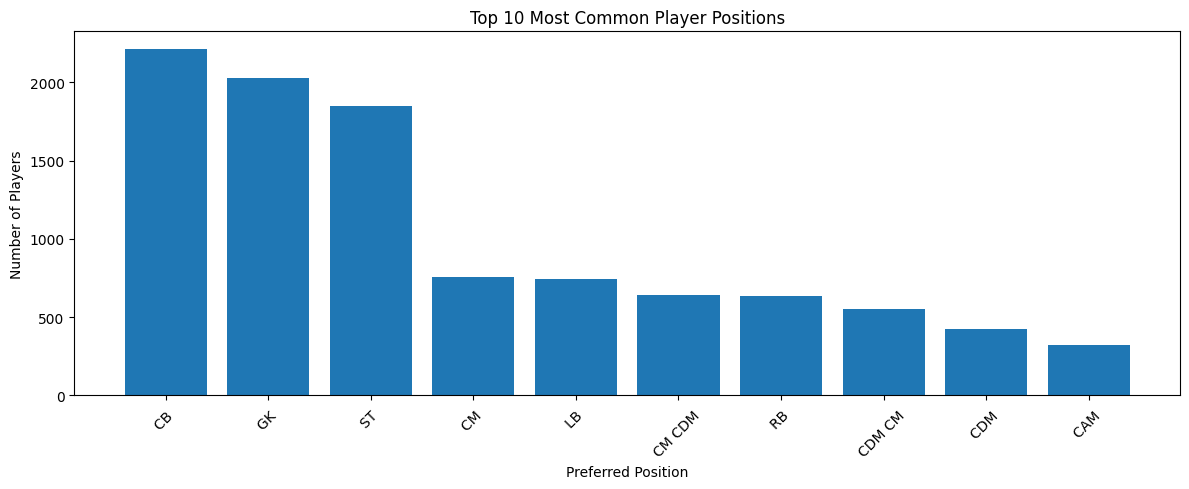

In [ ]:
position_stats = (
    df.groupBy("Preferred Positions")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

position_stats.show(10, truncate=False)

# Convert Spark results to Pandas for plotting
position_pd = position_stats.toPandas()

plt.figure(figsize=(12, 5))

plt.bar(
    position_pd["Preferred Positions"],
    position_pd["count"]
)

plt.title("Top 10 Most Common Player Positions")
plt.xlabel("Preferred Position")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
future_stars = (
    df.filter(
        (F.col("Age") <= 23) &
        (F.col("Potential") >= 85)
    )
    .select(
        "Name",
        "Age",
        "Nationality",
        "Club",
        "Overall",
        "Potential"
    )
    .orderBy(
        F.desc("Potential"),
        F.desc("Overall")
    )
)

future_stars.show(20, truncate=False)

print("Total high-potential young players:", future_stars.count())

+--------------+---+-----------+-----------------------+-------+---------+
|Name          |Age|Nationality|Club                   |Overall|Potential|
+--------------+---+-----------+-----------------------+-------+---------+
|K. Mbappé     |18 |France     |Paris Saint-Germain    |83     |94       |
|G. Donnarumma |18 |Italy      |Milan                  |82     |94       |
|P. Dybala     |23 |Argentina  |Juventus               |88     |93       |
|Marco Asensio |21 |Spain      |Real Madrid CF         |84     |92       |
|O. Dembélé    |20 |France     |FC Barcelona           |83     |92       |
|Gabriel Jesus |20 |Brazil     |Manchester City        |81     |92       |
|Bernardo Silva|22 |Portugal   |Manchester City        |84     |91       |
|T. Lemar      |21 |France     |AS Monaco              |83     |91       |
|L. Sané       |21 |Germany    |Manchester City        |82     |91       |
|H. Kane       |23 |England    |Tottenham Hotspur      |86     |90       |
|Y. Carrasco   |23 |Belgi

In [ ]:
print("""
====================================================
WEEK 2 — DATA PRE-PROCESSING AND VISUALISATION
FOOTBALL PLAYERS DATASET
====================================================

Dataset Analysis Completed Successfully

PySpark Skills Used:
• Spark DataFrames
• Data exploration
• Schema inspection
• Missing value analysis
• Duplicate removal
• Data filtering
• groupBy() operations
• Aggregation functions
• Sorting and ranking

Analysis Performed:
• Basic player statistics
• Top players by overall rating
• Nationality performance analysis
• Player age distribution
• Top clubs by average rating
• Overall rating vs potential analysis
• Most common player positions
• Young players with high potential

Conclusion:
PySpark DataFrames were used to efficiently process
and analyse a large football player dataset. The analysis
identified important patterns related to player ratings,
age, nationality, club performance and future potential.
====================================================
""")


WEEK 2 — DATA PRE-PROCESSING AND VISUALISATION
FOOTBALL PLAYERS DATASET

Dataset Analysis Completed Successfully

PySpark Skills Used:
• Spark DataFrames
• Data exploration
• Schema inspection
• Missing value analysis
• Duplicate removal
• Data filtering
• groupBy() operations
• Aggregation functions
• Sorting and ranking

Analysis Performed:
• Basic player statistics
• Top players by overall rating
• Nationality performance analysis
• Player age distribution
• Top clubs by average rating
• Overall rating vs potential analysis
• Most common player positions
• Young players with high potential

Conclusion:
PySpark DataFrames were used to efficiently process
and analyse a large football player dataset. The analysis
identified important patterns related to player ratings,
age, nationality, club performance and future potential.

